In [29]:
import sys
from pyprojroot import here
sys.path.insert(0, str(here()))

In [ ]:
import torch
import cv2
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
from src.segmentation import (
    build_training_loaders,
    segment_image,
    train_sky_model, show_augmentation_samples, plot_training_curves,
    IMAGENET_MEAN, IMAGENET_STD,
)


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running training on device: {device}")

geopose_dir  = here() / "data" / "geopose3k"
syn_img_dir  = here() / "data" / "synthetic_dataset" / "images"
syn_mask_dir = here() / "data" / "synthetic_dataset" / "masks"
model_save_path = here() / "data" / "sky_segmentation_unet_model.pth"

Running training on device: cpu


In [ ]:
train_loader, val_loader = build_training_loaders(
    geopose_dir, syn_img_dir, syn_mask_dir,
    batch_size=8, train_transform=train_transform,
)


Loading GeoPose3K dataset files...
Checking for synthetic dataset...
  Found 300 synthetic samples.
  Train samples: 2320 | Val samples: 575


In [4]:
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.Affine(
        translate_percent=0.1, 
        scale=(0.85, 1.15), 
        rotate=(-15, 15), 
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.6
    ),
    A.GridDistortion(
        border_mode=cv2.BORDER_REFLECT_101, 
        p=0.3
    ),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
    A.CLAHE(clip_limit=4.0, p=0.3),
    A.GaussNoise(p=0.2),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.MotionBlur(blur_limit=3, p=0.1),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

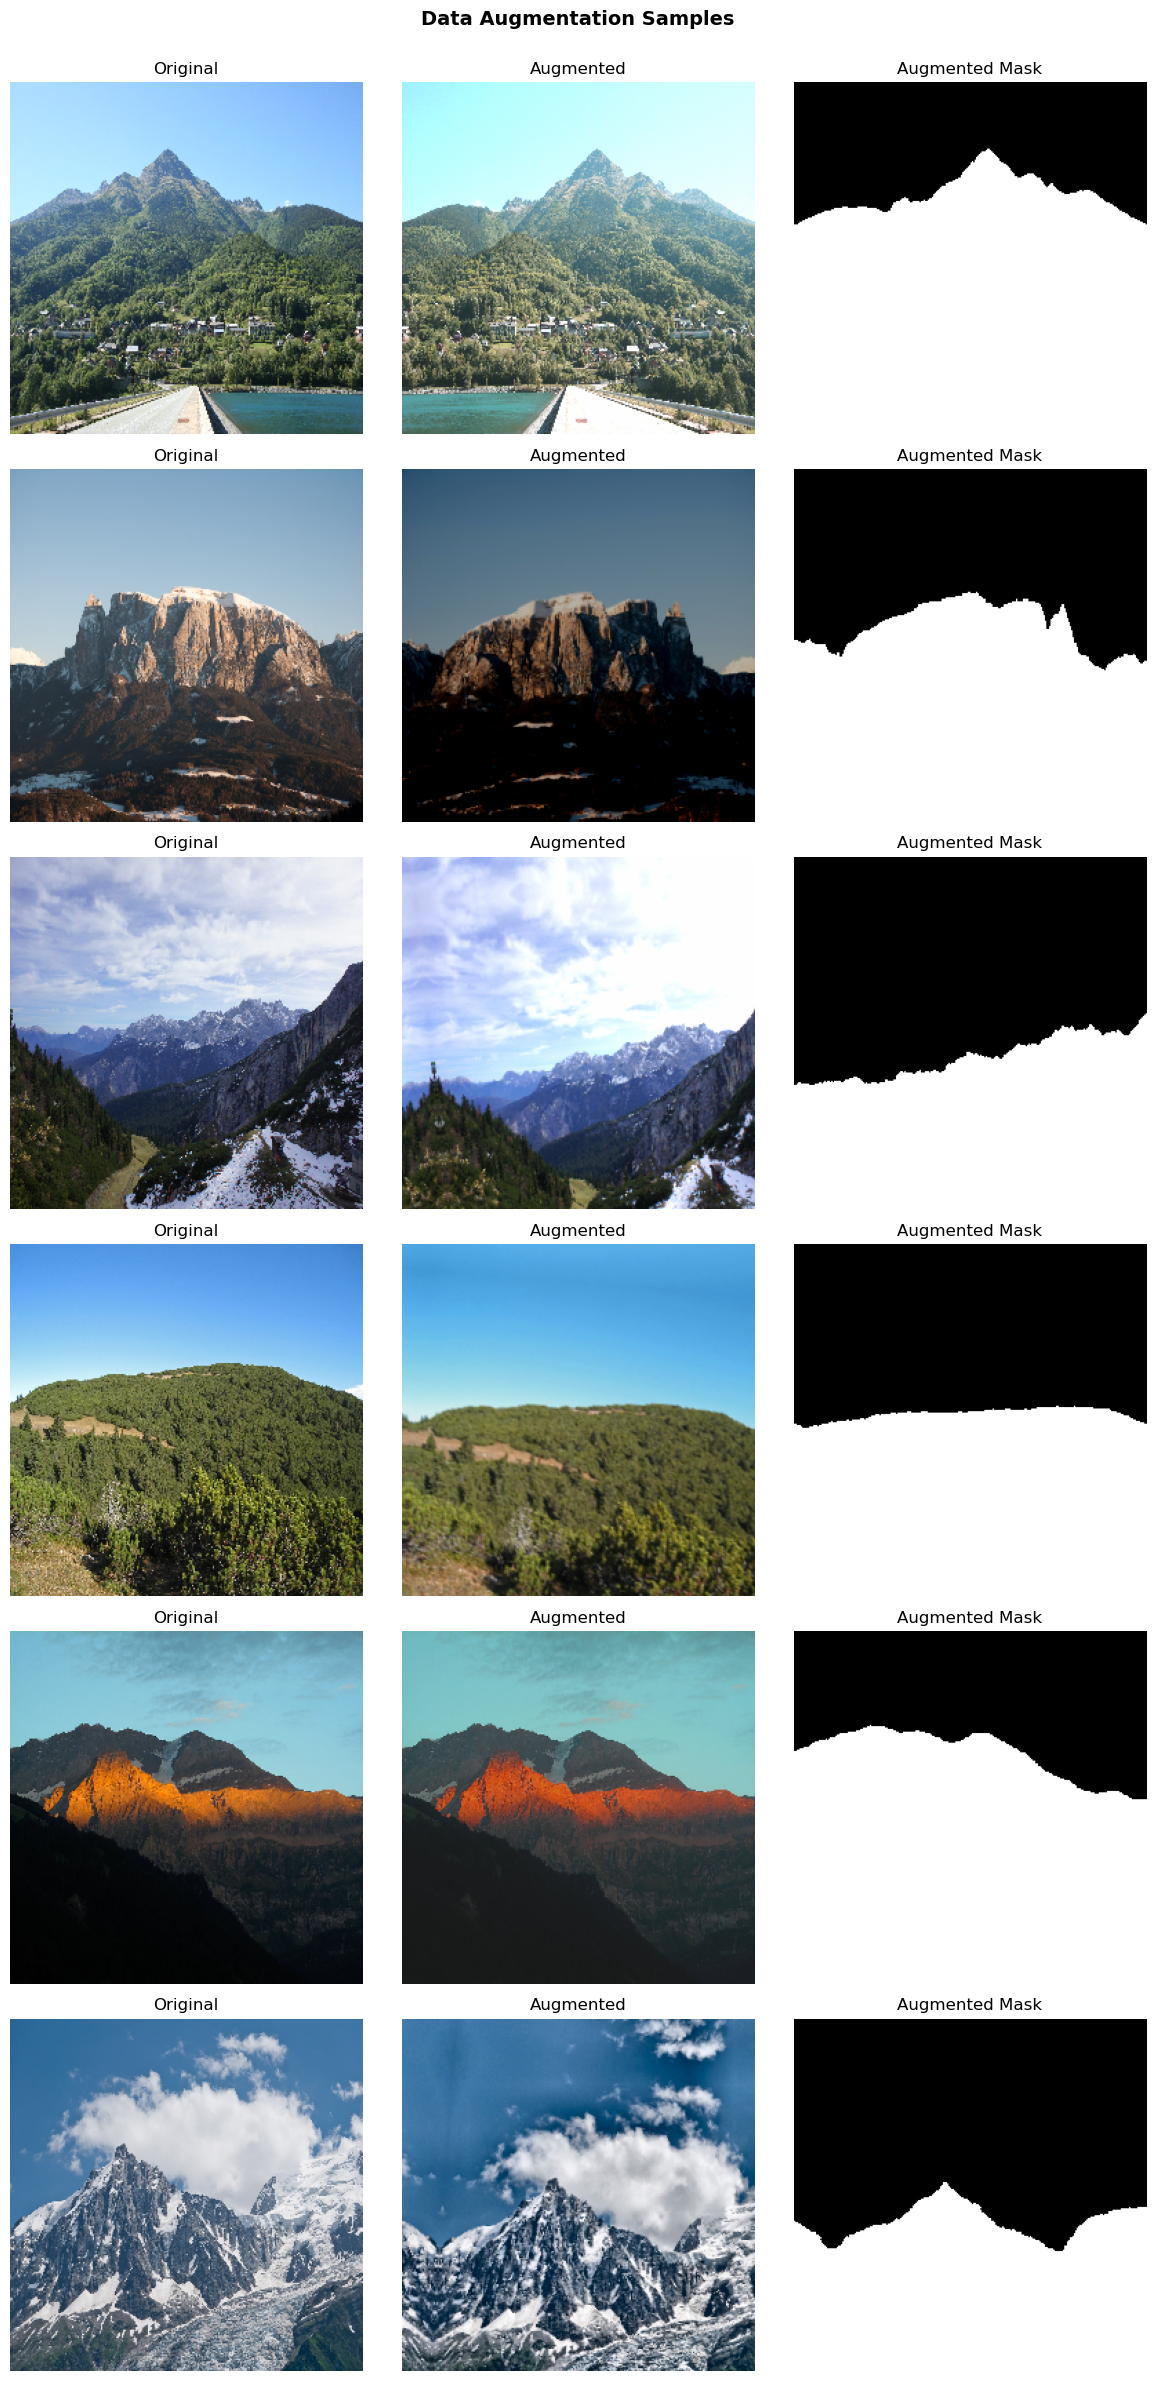

In [27]:
from src.segmentation import load_geopose_split

sample_imgs, sample_masks = load_geopose_split(
    geopose_dir / "splits" / "geoPose3K_final_train.txt", geopose_dir
)
show_augmentation_samples(sample_imgs, sample_masks, aug=train_transform, n=6)

In [9]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="tu-mobilenetv3_large_100",
    encoder_weights=True,
    in_channels=3,
    classes=1,
    activation=None,
).to(device)

Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [ ]:
train_losses, val_losses, train_ious, val_ious, lrs = train_sky_model(
    model, train_loader, val_loader, device,
    save_path=model_save_path, epochs=15, lr=2e-4,
)


<hr/>

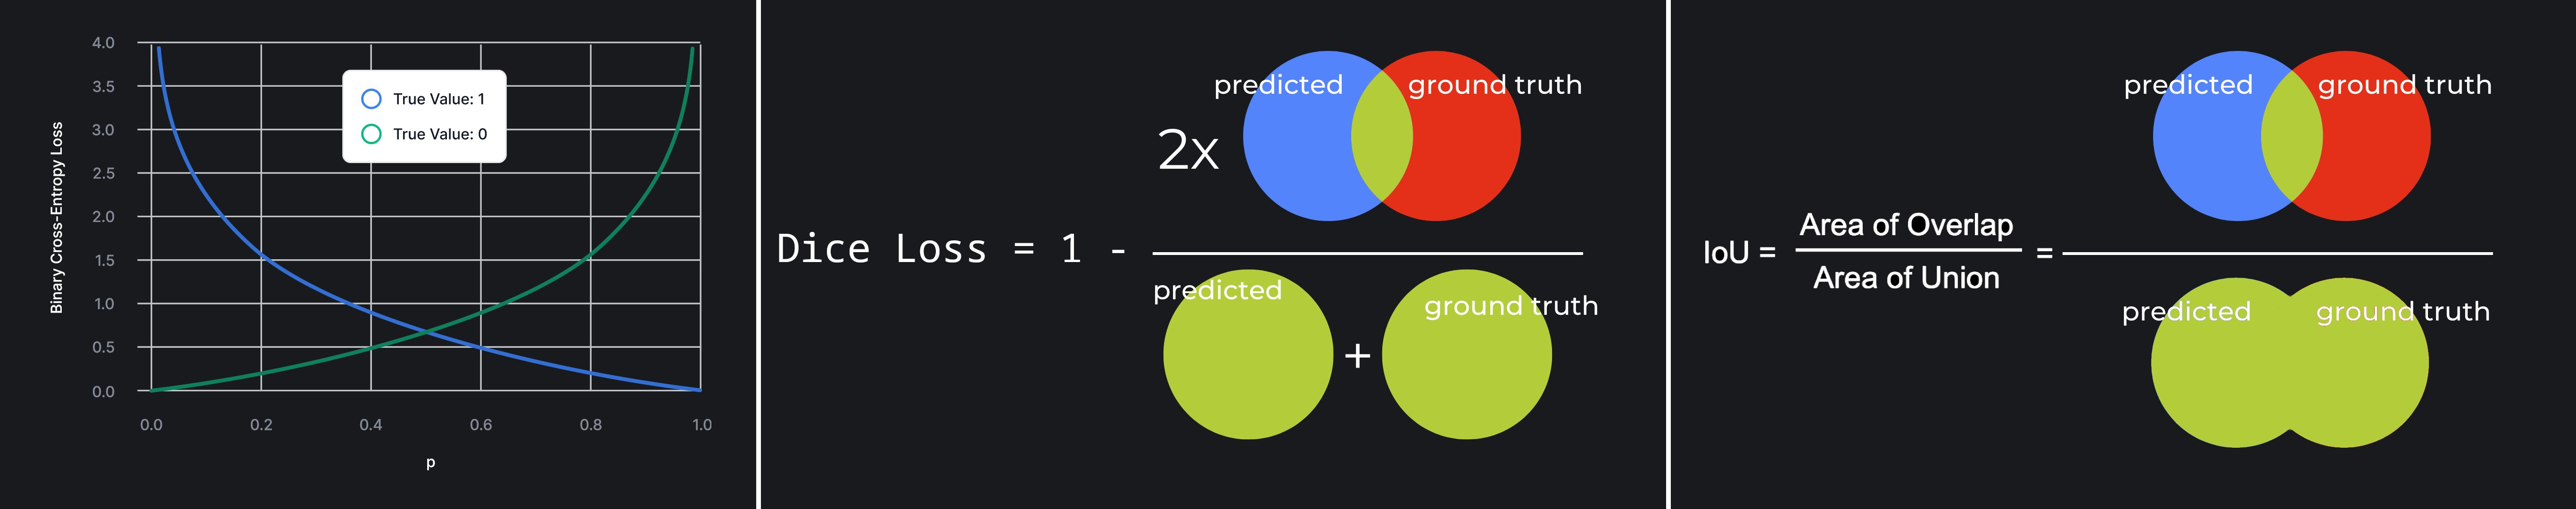

<hr/>

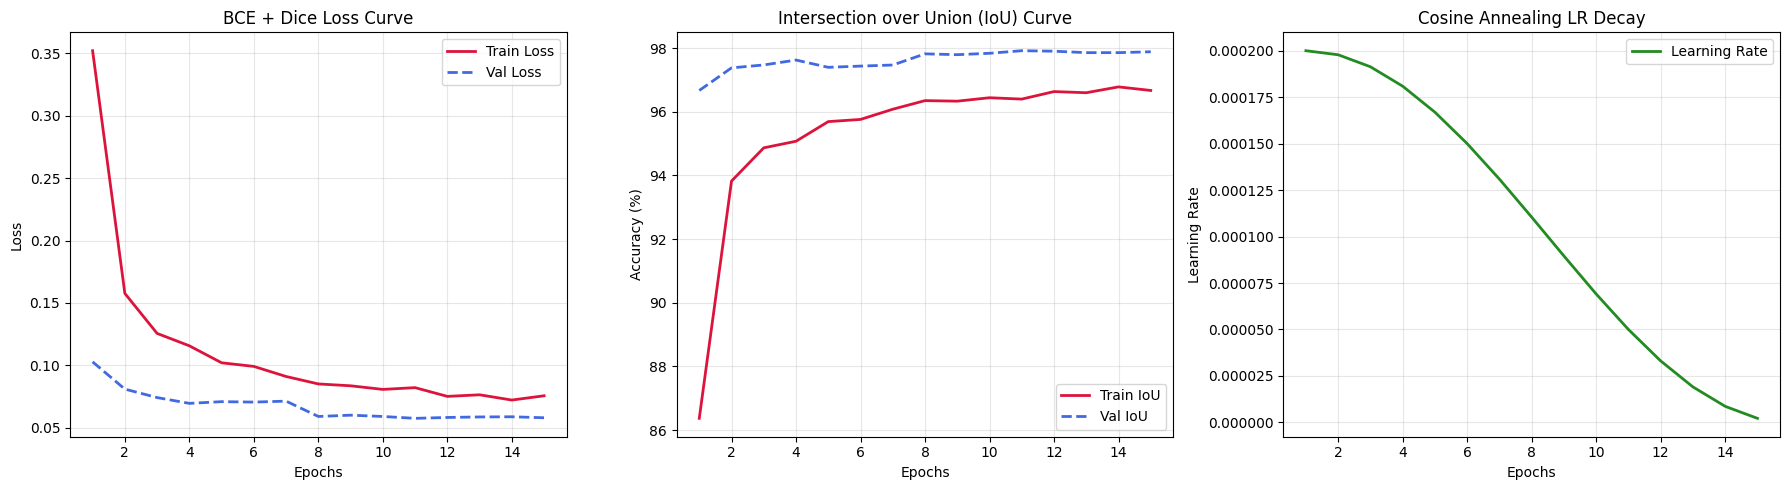

In [ ]:
plot_training_curves(train_losses, val_losses, train_ious, val_ious, lrs)